In [1]:
# TODO Save trial.user_attr range of parameters
# TODO For neuronal network visualizate by epoch
# TODO Summary protocol

In [14]:
from utilsOptuna import remove_study_from_storage

remove_study_from_storage('sqlite:///optuna_DL_exercise.db', 'MDL_mmodal3_img1_meta1_emb1')

Study 'MDL_mmodal3_img1_meta1_emb1' deleted successfully


In [15]:
from utilsOptuna import info_studies_from_storage

storage = 'sqlite:///optuna_DL_exercise.db'
print(f"Storage: {storage}")
info_studies_from_storage(storage)

Storage: sqlite:///optuna_DL_exercise.db


,study_name,best_score,description
0,MDL_fcnn_pca_embeddings1,0.661972,FCNN with Progressive Compression Architecture...
1,MDL_fcnn_shallow_metadata1,0.794613,Shallow FCNN using metadata


In [15]:
import optuna

storage = 'sqlite:///optuna_DL_exercise.db'
study_name = 'fcnn_shallow_metadata1'
study = optuna.load_study(
    study_name = study_name,
    storage = storage
)

In [16]:
# info save in study
print(study.user_attrs)
# info save in trial
print(study.best_trial)

{'comments': 'Shallow FCNN using metadata', 'dataset': 'poi_dataset.csv', 'preproc_data': {'name': 'process_data', 'module': 'utilsProc'}, 'proc_features': {'type': 'ColumnTransformer', 'transformers': [{'name': 'numerical', 'columns': ['xps', 'locationLon', 'locationLat', 'NumTags'], 'transformer': {'class': 'StandardScaler', 'module': 'sklearn.preprocessing._data'}}, {'name': 'categories', 'columns': ['categories'], 'transformer': {'class': 'MultiLabelBinarizerWrapper', 'module': 'utilsFT'}}, {'name': 'tier', 'columns': ['tier'], 'transformer': {'class': 'OneHotEncoder', 'module': 'sklearn.preprocessing._encoders'}}]}, 'script': './fcnn_shallow_metadata1.py', 'split_test': {'test_size': 0.2}, 'split_val': {'test_size': 0.2}, 'train_config': {'train': {'name': 'ModelTrain', 'module': 'utilsTrain'}, 'model': {'name': 'FCNN_shallow', 'module': 'utilsNN'}, 'criterion': {'name': 'CrossEntropyLoss', 'module': 'torch.nn.modules.loss'}, 'optimizer': {'name': 'Adam', 'module': 'torch.optim.ad

In [10]:
from utilsOptuna import info_runs_from_study

# get info for runs of a study
print(f"Storage: {storage}")
print(f"Study: {study_name}")
#info_runs_from_study(study.trials, extended=True)
info_runs_from_study(study.trials)


Storage: sqlite:///optuna_DL_exercise.db
Study: fcnn_pca_embeddings1


,run,num_trials,completed_trials,best_score
0,base_run,10,9,0.705882
1,extension1_run,10,5,0.678322
2,extension2_run,10,5,0.643357


In [5]:
from utilsOptuna import optuna_results

# output for best_trial
print(f"Storage: {storage}")
print(f"Study: {study_name}")
optuna_results(study)

Storage: sqlite:///optuna_DL_exercise.db
Study: fcnn_pca_embeddings1
Best trial:
  Value:  0.7058823529411765
  Params: 
			Value
    batch_size:	2.00000
    dropout_rate:	0.37382
    lr:	0.01876


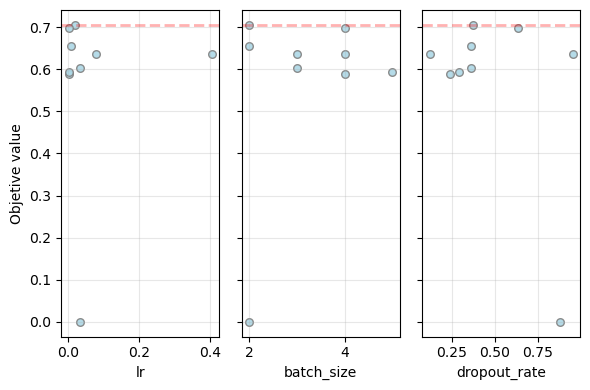

In [6]:
from utilsOptuna import plot_slice

# TODO Custom plot_slice adapt log variables to axis scale
# TODO Custom plot_slice select highest trials
# TODO Select run
plot_slice(study) # Slice plot param vs objetiveValue

/tmp/ipykernel_106169/3579258984.py:5: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study, params=['batch_size', 'dropout_rate']) # 2D contour plot


<Axes: title={'center': 'Contour Plot'}, xlabel='batch_size', ylabel='dropout_rate'>

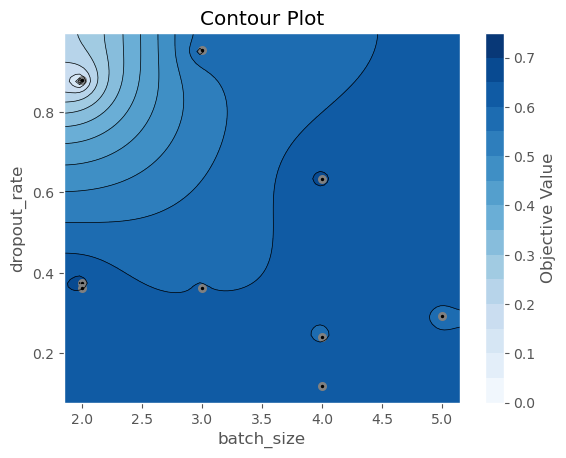

In [8]:
import optuna

# TODO plot optimized hyperparameters
# TODO Make custom plot_contour. Highlight best result.
optuna.visualization.matplotlib.plot_contour(study, params=['batch_size', 'dropout_rate']) # 2D contour plot


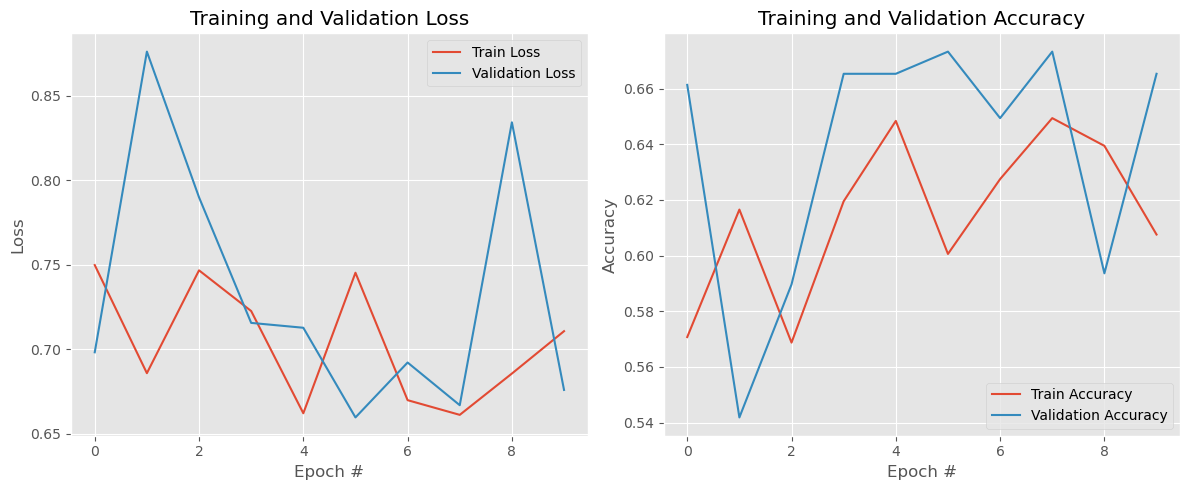

In [ ]:
from utilsOptuna import plot_train_nn

trial = study.best_trial
plot_train_nn(trial)

In [ ]:
# TODO How to calculate importance features. Is strange? Most importance to max_depth and n_estimators?
#optuna.visualization.matplotlib.plot_param_importances(study,evaluator=optuna.importance.FanovaImportanceEvaluator())